# Module 1 — Business-cycle facts & filtering

**Course companion · puremacro**

### Learning objectives
By the end of this lesson you can:
1. **Detrend** a macro time series into trend and cyclical components.
2. Contrast the **Hodrick–Prescott** filter with the **Hamilton (2018)** filter.
3. Compute the **business-cycle facts** — relative volatility, comovement, persistence.
4. Read the **spectral** view: how much variance sits in the 6–32-quarter band.

Everything here runs in pure Python (browser/iPad, $0).

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

_cwd = __import__("pathlib").Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor

## 1. Trend and cycle

A macro series $y_t$ (log GDP, say) mixes a slow-moving **trend** $\tau_t$ and a
**cyclical** component $c_t = y_t - \tau_t$. Business-cycle analysis is about the
cycle: how volatile it is, how it comoves across variables, and how persistent it
is. The hard part is *defining the trend*.

### Two filters
- **Hodrick–Prescott (HP):** picks $\tau_t$ to trade off fit against smoothness,
  controlled by $\lambda$ (1600 for quarterly data).
- **Hamilton (2018):** regress $y_{t+h}$ on its own recent lags; the residual is the
  cycle. Hamilton argues the HP filter induces *spurious* dynamics ("Why You Should
  Never Use the Hodrick–Prescott Filter") and proposes this regression alternative.

`puremacro` ships both — `data.hp_filter` and `cycles.hamilton_filter` — in pure NumPy.

## 2. A worked example
We simulate a log-GDP series (deterministic growth trend + an ~24-quarter cycle +
noise) and a comoving "consumption" series, then extract the cycle two ways.

In [2]:
from puremacro.data import hp_filter
from puremacro.cycles import hamilton_filter
from puremacro.spectral import business_cycle_band_power

rng = np.random.default_rng(20260531)
T = 240                                   # 60 years, quarterly
t = np.arange(T)
trend = 100.0 + 0.4 * t                   # deterministic growth trend (log points)
bc = np.zeros(T)                          # an AR(2) business-cycle component
for i in range(2, T):
    bc[i] = 1.55 * bc[i - 1] - 0.70 * bc[i - 2] + rng.standard_normal()
bc = 2.0 * bc / bc.std()                  # scale to ~2 log points
gdp = trend + bc + 0.3 * rng.standard_normal(T)
cons = 0.95 * trend + 0.6 * bc + 0.4 * rng.standard_normal(T)  # comoves, less volatile

hp_cycle, hp_trend = hp_filter(gdp)               # (cycle, trend), cycle has mean ~0
ham_cycle, ham_trend = hamilton_filter(gdp)       # (cycle, trend); first h+p obs are NaN

### The two cyclical components
Both isolate the ~24-quarter swings; the Hamilton filter is defined only after its
warm-up (the first quarters are dropped) and tends to leave a larger-amplitude cycle.

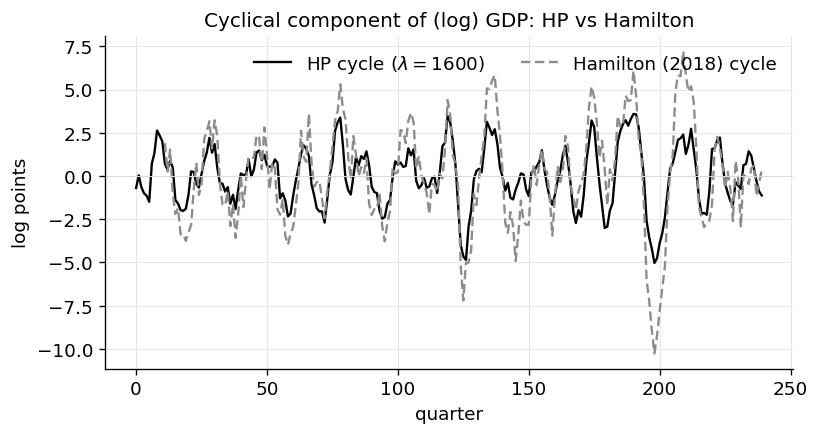

In [3]:
cols = _nbstyle.palette(2)
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot(t, np.asarray(hp_cycle), color=cols[0], lw=1.4, label="HP cycle ($\\lambda=1600$)")
ax.plot(t, np.asarray(ham_cycle), color="0.55", lw=1.4, ls=(0, (4, 2)), label="Hamilton (2018) cycle")
ax.axhline(0, color="0.85", lw=0.6)
ax.set_xlabel("quarter"); ax.set_ylabel("log points")
ax.set_title("Cyclical component of (log) GDP: HP vs Hamilton")
ax.legend(loc="upper right", ncol=2)
plt.show()

### Business-cycle facts
On the HP cycle: relative volatility of consumption, persistence (first-order
autocorrelation), comovement (correlation of the GDP and consumption cycles), and
the spectral share of variance in the 6–32-quarter band.

In [4]:
cons_cycle, _ = hp_filter(cons)
cons_cycle = np.asarray(cons_cycle); g = np.asarray(hp_cycle)

rel_vol = cons_cycle.std() / g.std()
persistence = np.corrcoef(g[1:], g[:-1])[0, 1]
comovement = np.corrcoef(g, cons_cycle)[0, 1]
band_share = business_cycle_band_power(g)

print(f"relative volatility  sd(cons)/sd(gdp) = {rel_vol:.2f}")
print(f"persistence  corr(c_t, c_t-1)          = {persistence:.2f}")
print(f"comovement   corr(gdp, cons) cycles     = {comovement:.2f}")
print(f"spectral share in 6-32q band            = {band_share:.2f}")

assert 0.0 < band_share <= 1.0
assert comovement > 0.5            # consumption comoves with output

relative volatility  sd(cons)/sd(gdp) = 0.63
persistence  corr(c_t, c_t-1)          = 0.86
comovement   corr(gdp, cons) cycles     = 0.93
spectral share in 6-32q band            = 0.93


## 3. Hands-on lab
Work through the feature notebooks for more: **`notebooks/09_growth_at_risk`** (the
distributional view of the cycle) and the **`spectral`** validation cases
(`puremacro.validation`, subsystem `spectral`) for the Welch machinery used here.

## 4. Exercises
1. Re-run with $\lambda = 6.25$ (annual) and $\lambda = 129{,}600$ (monthly). How does
   the HP cycle change?
2. Vary the Hamilton horizon `h` (e.g. 4, 8, 12). What happens to the warm-up loss and
   the cycle amplitude?
3. Add a second, *less* comoving series and recompute the comovement table.
4. Compute `business_cycle_band_power` on the **raw** `gdp` vs the HP cycle — why do
   they differ so much?

### Solutions (sketch)
1. Smaller $\lambda$ → trend tracks the data more closely → smaller, higher-frequency
   cycle; larger $\lambda$ → smoother trend → larger, lower-frequency cycle.
2. Larger `h` drops more initial observations and generally yields a larger-amplitude,
   lower-frequency cycle.
3. A series with own-noise weight raised relative to the shared `bc` term shows lower
   comovement.
4. The raw series is trend-dominated (most variance at the lowest frequencies), so its
   6–32q share is small; the HP cycle is detrended, so its mass sits in the band.

## 5. Explore with AI
Try these with the offline tutor (or any AI assistant):
- "Why did Hamilton (2018) argue against the HP filter? Give the one-sentence intuition."
- "If consumption is *less* volatile than output but strongly comoving, what does that
  say about consumption smoothing?"

In [5]:
print(tutor("In one sentence, why did Hamilton (2018) argue against the HP filter?"))

[tutor offline] No local LLM engine is available here (expected in the browser). Install one with `pip install puremacro[local-llm]` and a small model (e.g. via Ollama or MLX), or use the AI-exploration prompts below with any AI assistant.
(engine note: HFValidationError)


**Recap.** We decomposed a series into trend and cycle two ways (HP vs Hamilton),
read off the canonical business-cycle facts (relative volatility, persistence,
comovement), and quantified the cycle's spectral mass — all in pure-Python
`puremacro`, runnable in the browser. **Next module:** the neoclassical growth model
by value-function iteration.